<a href="https://colab.research.google.com/github/Dhruvjain484/Machine_learning_projects_for_beginner_part_2/blob/main/Hotel_booking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [277]:
# importing the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [278]:
# importing the dataset 

dataset = pd.read_csv('hotel_bookings.csv')
dataset.shape

(119390, 32)

In [279]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [280]:
dataset.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [281]:
dataset.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [282]:
# taking care of missing data 

def show_data(df):
  df.fillna(0, inplace = True)
  print(df.isnull().sum())

In [283]:
show_data(dataset)

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [284]:
dataset.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,7/3/2015


In [285]:


import warnings
from warnings import filterwarnings
filterwarnings('ignore')

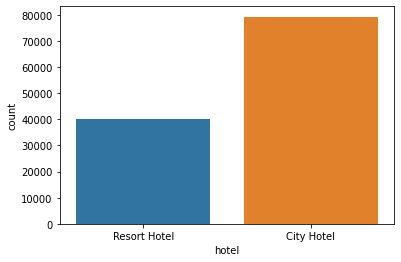

In [286]:
sns.countplot(dataset['hotel']);

In [287]:
# removing outliers from the data

filter = (dataset['adults'] == 0) & (dataset['children'] == 0) & (dataset['babies'] ==0)
dataset[filter].shape

(180, 32)

In [288]:
dataset = dataset[~filter]

In [289]:
dataset.shape

(119210, 32)

In [290]:
# plotting the number of customers from different country

country_wise_data = dataset[dataset['is_canceled'] == 0]['country'].value_counts().reset_index()
country_wise_data.columns = ['country', 'count']
country_wise_data

,country,count
0,PRT,20977
1,GBR,9668
2,FRA,8468
3,ESP,6383
4,DEU,6067
...,...,...
161,BDI,1
162,ATF,1
163,NAM,1
164,KIR,1


In [291]:
map = px.choropleth(country_wise_data, locations= country_wise_data['country'], title= 'country wise customer', color = country_wise_data['count'], hover_name= country_wise_data['country'], height = 550, width = 600)
map.show()

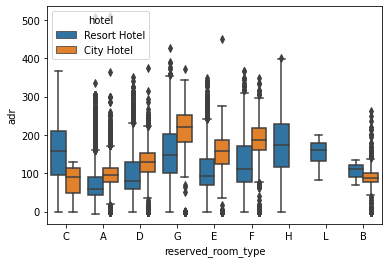

In [292]:
data2 = dataset[dataset['is_canceled'] ==0]
sns.boxplot(data = data2, x = 'reserved_room_type', y = 'adr', hue = 'hotel')

In [293]:
resort_hotel = dataset[dataset['hotel'] == 'Resort Hotel']

city_hotel = dataset[dataset['hotel'] ==  'City Hotel']

In [294]:
!pip install sort-dataframeby-monthorweek

In [295]:
!pip install sorted-months-weekdays

In [296]:
# month wise hotel charges

resort_hotel_mp = resort_hotel.groupby(['arrival_date_month'])['adr'].mean().reset_index()

city_hotel_mp = city_hotel.groupby(['arrival_date_month'])['adr'].mean().reset_index()


hotel_month_price = resort_hotel_mp.merge(city_hotel_mp, on = 'arrival_date_month')
hotel_month_price.columns = ['month', 'resort_hotel', 'city_hotel']
hotel_month_price

,month,resort_hotel,city_hotel
0,April,77.849496,111.397415
1,August,186.790574,114.857330
2,December,69.051887,89.209560
3,February,55.189716,85.327519
4,January,49.507033,82.754477
5,July,155.181299,110.945950
6,June,110.481032,119.186056
7,March,57.554652,92.973339
8,May,78.758134,121.764614
9,November,48.313643,88.372486


In [297]:
import sort_dataframeby_monthorweek as sd
def sorted_by_month(df, columns):
  return sd.Sort_Dataframeby_Month(df, columns)

In [298]:
hotel_month_price = sorted_by_month(hotel_month_price, 'month')
hotel_month_price

,month,resort_hotel,city_hotel
0,January,49.507033,82.754477
1,February,55.189716,85.327519
2,March,57.554652,92.973339
3,April,77.849496,111.397415
4,May,78.758134,121.764614
5,June,110.481032,119.186056
6,July,155.181299,110.945950
7,August,186.790574,114.857330
8,September,93.252030,110.120296
9,October,62.132572,100.119313


In [299]:
# function to display different features with respect to month

def plot(df):

  fig = px.line()

  for i in df.columns[1:]:
    fig.add_scatter(x = df['month'], y = df[i], name = i)

  fig.show()

In [300]:
plot(hotel_month_price)

In [301]:
# number of customers(rush) in both the hotels during every month 

rush_resort = resort_hotel['arrival_date_month'].value_counts().reset_index()
rush_resort.columns = ['month', 'resort_hotel_customers']

rush_city = city_hotel['arrival_date_month'].value_counts().reset_index()
rush_city.columns = ['month', 'city_hotel_customers']

rush = rush_resort.merge(rush_city, on = 'month')


In [302]:
rush = sorted_by_month(rush, 'month')
rush

,month,resort_hotel_customers,city_hotel_customers
0,January,2191,3730
1,February,3102,4950
2,March,3334,6434
3,April,3609,7469
4,May,3559,8221
5,June,3044,7885
6,July,4573,8071
7,August,4894,8967
8,September,3108,7392
9,October,3553,7594


In [303]:
plot(rush)

In [304]:
# finding the correlations of different features wrt hotel booking cancelation

correlation = dataset.corr()['is_canceled'].sort_values(ascending = False)
correlation

is_canceled                       1.000000
lead_time                         0.292876
previous_cancellations            0.110139
adults                            0.058182
days_in_waiting_list              0.054301
adr                               0.046492
stays_in_week_nights              0.025542
arrival_date_year                 0.016622
arrival_date_week_number          0.008315
children                          0.004851
stays_in_weekend_nights          -0.001323
arrival_date_day_of_month        -0.005948
babies                           -0.032569
agent                            -0.046770
previous_bookings_not_canceled   -0.057365
company                          -0.083594
is_repeated_guest                -0.083745
booking_changes                  -0.144832
required_car_parking_spaces      -0.195701
total_of_special_requests        -0.234877
Name: is_canceled, dtype: float64

In [305]:
dataset.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0.0,0.0,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0.0,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0.0,0,Transient,98.0,0,1,Check-Out,7/3/2015


In [306]:
#removing unwanted numerical features

num_features_not_req = ['arrival_date_year', 'days_in_waiting_list']
num_features = []

for col in dataset.columns[1:]:
  if dataset[col].dtype !='O' and col not in num_features_not_req:
    num_features.append(col)

num_features    

['is_canceled',
 'lead_time',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [307]:
dataset_num = dataset[num_features]

In [309]:
#removing unwanted categorical features

categorical_features_not_req =  ['assigned_room_type', 'reservation_status', 'country']
categorical_features = []

for col in dataset.columns:
  if dataset[col].dtype =='O' and col not in categorical_features_not_req:
    categorical_features.append(col)

categorical_features

['hotel',
 'arrival_date_month',
 'meal',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status_date']

In [310]:
dataset_cat = dataset[categorical_features]
dataset_cat.head()

,hotel,arrival_date_month,meal,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type,reservation_status_date
0,Resort Hotel,July,BB,Direct,Direct,C,No Deposit,Transient,7/1/2015
1,Resort Hotel,July,BB,Direct,Direct,C,No Deposit,Transient,7/1/2015
2,Resort Hotel,July,BB,Direct,Direct,A,No Deposit,Transient,7/2/2015
3,Resort Hotel,July,BB,Corporate,Corporate,A,No Deposit,Transient,7/2/2015
4,Resort Hotel,July,BB,Online TA,TA/TO,A,No Deposit,Transient,7/3/2015


In [311]:
#converting data type of object into datetime

dataset_cat['reservation_status_date'] = pd.to_datetime(dataset_cat['reservation_status_date'])

In [312]:
dataset_cat['year'] = dataset_cat['reservation_status_date'].dt.year
dataset_cat['month'] = dataset_cat['reservation_status_date'].dt.month
dataset_cat['day'] = dataset_cat['reservation_status_date'].dt.day

In [313]:
dataset_cat = dataset_cat.drop('reservation_status_date', axis = 1)
dataset_cat.head()

,hotel,arrival_date_month,meal,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type,year,month,day
0,Resort Hotel,July,BB,Direct,Direct,C,No Deposit,Transient,2015,7,1
1,Resort Hotel,July,BB,Direct,Direct,C,No Deposit,Transient,2015,7,1
2,Resort Hotel,July,BB,Direct,Direct,A,No Deposit,Transient,2015,7,2
3,Resort Hotel,July,BB,Corporate,Corporate,A,No Deposit,Transient,2015,7,2
4,Resort Hotel,July,BB,Online TA,TA/TO,A,No Deposit,Transient,2015,7,3


In [314]:
dataset_cat['cancelation'] = dataset['is_canceled']
dataset_cat.head()

,hotel,arrival_date_month,meal,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type,year,month,day,cancelation
0,Resort Hotel,July,BB,Direct,Direct,C,No Deposit,Transient,2015,7,1,0
1,Resort Hotel,July,BB,Direct,Direct,C,No Deposit,Transient,2015,7,1,0
2,Resort Hotel,July,BB,Direct,Direct,A,No Deposit,Transient,2015,7,2,0
3,Resort Hotel,July,BB,Corporate,Corporate,A,No Deposit,Transient,2015,7,2,0
4,Resort Hotel,July,BB,Online TA,TA/TO,A,No Deposit,Transient,2015,7,3,0


In [315]:
#converting categorical data into numerical data

cols = dataset_cat.columns[0:8]
for col in cols:
  dict = dataset_cat.groupby([col])['cancelation'].mean().to_dict()
  dataset_cat[col] = dataset_cat[col].map(dict)

In [316]:
dataset_cat

,hotel,arrival_date_month,meal,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type,year,month,day,cancelation
0,0.277674,0.374644,0.374106,0.153712,0.174868,0.330827,0.28402,0.407864,2015,7,1,0
1,0.277674,0.374644,0.374106,0.153712,0.174868,0.330827,0.28402,0.407864,2015,7,1,0
2,0.277674,0.374644,0.374106,0.153712,0.174868,0.391567,0.28402,0.407864,2015,7,2,0
3,0.277674,0.374644,0.374106,0.187618,0.220568,0.391567,0.28402,0.407864,2015,7,2,0
4,0.277674,0.374644,0.374106,0.367590,0.410598,0.391567,0.28402,0.407864,2015,7,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0.417859,0.377823,0.374106,0.343313,0.410598,0.391567,0.28402,0.407864,2017,9,6,0
119386,0.417859,0.377823,0.374106,0.367590,0.410598,0.292683,0.28402,0.407864,2017,9,7,0
119387,0.417859,0.377823,0.374106,0.367590,0.410598,0.318108,0.28402,0.407864,2017,9,7,0
119388,0.417859,0.377823,0.374106,0.367590,0.410598,0.391567,0.28402,0.407864,2017,9,7,0


In [317]:
# combining the numerical and categorical features into singel dataframe

dataframe = pd.concat([dataset_cat, dataset_num], axis = 1)
dataframe.drop('is_canceled', axis = 1, inplace = True)
dataframe.head()

,hotel,arrival_date_month,meal,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type,year,month,day,cancelation,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,adr,required_car_parking_spaces,total_of_special_requests
0,0.277674,0.374644,0.374106,0.153712,0.174868,0.330827,0.28402,0.407864,2015,7,1,0,342,27,1,0,0,2,0.0,0,0,0,0,3,0.0,0.0,0.0,0,0
1,0.277674,0.374644,0.374106,0.153712,0.174868,0.330827,0.28402,0.407864,2015,7,1,0,737,27,1,0,0,2,0.0,0,0,0,0,4,0.0,0.0,0.0,0,0
2,0.277674,0.374644,0.374106,0.153712,0.174868,0.391567,0.28402,0.407864,2015,7,2,0,7,27,1,0,1,1,0.0,0,0,0,0,0,0.0,0.0,75.0,0,0
3,0.277674,0.374644,0.374106,0.187618,0.220568,0.391567,0.28402,0.407864,2015,7,2,0,13,27,1,0,1,1,0.0,0,0,0,0,0,304.0,0.0,75.0,0,0
4,0.277674,0.374644,0.374106,0.367590,0.410598,0.391567,0.28402,0.407864,2015,7,3,0,14,27,1,0,2,2,0.0,0,0,0,0,0,240.0,0.0,98.0,0,1


In [318]:
dataframe.shape

(119210, 29)

#handling outliers

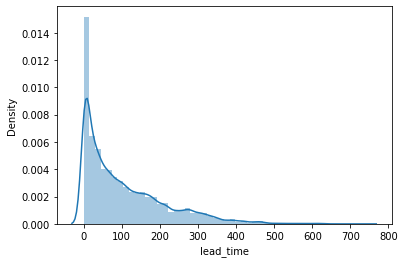

In [319]:
sns.distplot(dataframe['lead_time'])


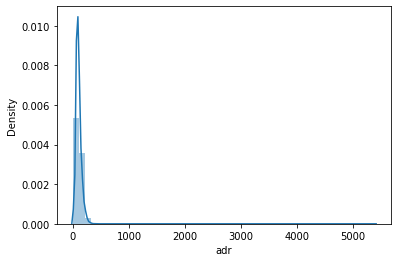

In [320]:
sns.distplot(dataframe['adr'])

In [321]:
def handle_outliers(col):
  dataframe[col] = np.log1p(dataframe[col])

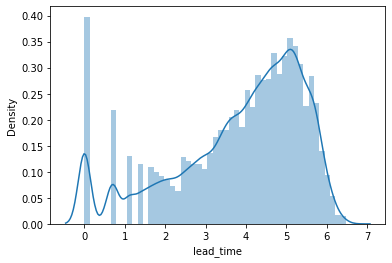

In [322]:
handle_outliers('lead_time')
sns.distplot(dataframe['lead_time'])

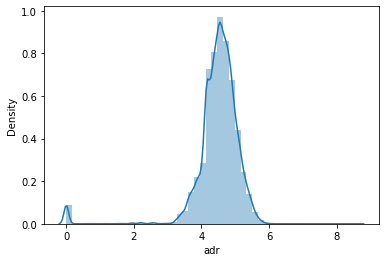

In [323]:
handle_outliers('adr')
sns.distplot(dataframe['adr'])

In [324]:
dataframe.isnull().sum()

hotel                             0
arrival_date_month                0
meal                              0
market_segment                    0
distribution_channel              0
reserved_room_type                0
deposit_type                      0
customer_type                     0
year                              0
month                             0
day                               0
cancelation                       0
lead_time                         0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
agent                             0
company                           0
adr                               1
required_car_parking_spaces 

In [325]:
dataframe.dropna(inplace= True)

In [326]:
X = dataframe.drop('cancelation', axis = 1)
y = dataframe['cancelation']

In [327]:
#selecting useful features to train classifier model

from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

In [328]:
feature_sel_model = SelectFromModel(Lasso(alpha= 0.005, random_state = 0))
feature_sel_model.fit(X, y)

SelectFromModel(estimator=Lasso(alpha=0.005, copy_X=True, fit_intercept=True,
                                max_iter=1000, normalize=False, positive=False,
                                precompute=False, random_state=0,
                                selection='cyclic', tol=0.0001,
                                warm_start=False),
                max_features=None, norm_order=1, prefit=False, threshold=None)

In [329]:
feature_sel_model.get_support()

array([False, False, False, False, False, False,  True, False,  True,
        True,  True,  True,  True, False, False, False,  True,  True,
       False, False,  True, False,  True, False,  True,  True,  True,
        True])

In [330]:
cols = X.columns

In [331]:
sel_features = cols[feature_sel_model.get_support()]

In [333]:
X = X[sel_features]
X

,deposit_type,year,month,day,lead_time,arrival_date_week_number,adults,children,previous_cancellations,booking_changes,company,adr,required_car_parking_spaces,total_of_special_requests
0,0.28402,2015,7,1,5.837730,27,2,0.0,0,3,0.0,0.000000,0,0
1,0.28402,2015,7,1,6.603944,27,2,0.0,0,4,0.0,0.000000,0,0
2,0.28402,2015,7,2,2.079442,27,1,0.0,0,0,0.0,4.330733,0,0
3,0.28402,2015,7,2,2.639057,27,1,0.0,0,0,0.0,4.330733,0,0
4,0.28402,2015,7,3,2.708050,27,2,0.0,0,0,0.0,4.595120,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,0.28402,2017,9,6,3.178054,35,2,0.0,0,0,0.0,4.576153,0,0
119386,0.28402,2017,9,7,4.634729,35,3,0.0,0,0,0.0,5.422436,0,2
119387,0.28402,2017,9,7,3.555348,35,2,0.0,0,0,0.0,5.067079,0,4
119388,0.28402,2017,9,7,4.700480,35,2,0.0,0,0,0.0,4.657763,0,0


In [336]:
# splitting data into train and test data

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y , random_state = 0)

In [351]:
# applying classification model

from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier()
classifier.fit(x_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [352]:
y_pred = classifier.predict(x_test)

In [353]:
# confusion matrix

from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[18509,   130],
       [ 1285,  9879]])

In [354]:
accuracy_score(y_test,y_pred)

0.9525215582323927